# Simulación de Inventario 

In [20]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Cargado dataset

In [11]:
df = pd.read_csv("../processed/df_model_CA1.csv")
df["date"] = pd.to_datetime(df["date"])

### Cargando el modelo 

In [12]:
model = joblib.load("demand_forecasting_model.pkl")

In [13]:
features = [
"sell_price",
"is_weekend",
"has_event",
"dayofweek",
"month",
"year",
"lag_7",
"lag_28",
"rolling_mean_7",
"rolling_mean_28"
]

preds = model.predict(df[features])

In [15]:
#Calcular inventario 
daily_demand = preds.mean()
sigma = preds.std()

lead_time = 3
z = 1.65

safety_stock = z * sigma * np.sqrt(lead_time)
reorder_point = daily_demand * lead_time + safety_stock


In [16]:
safety_stock

10.344775993363935

El sistema recomienda mantener 10 unidades extra como protección ante incertidumbre

In [17]:
reorder_point

15.246190809503334

Cuano el inventario baje ~15 unidades, se debe realizar un pedido.

### Simulación Simple de inventario

In [22]:
order_quantity = 20
inventory_levels = []

for demand in preds[:60]:

    inventory -= demand

    if inventory <= reorder_point:
        inventory += order_quantity

    inventory_levels.append(inventory)

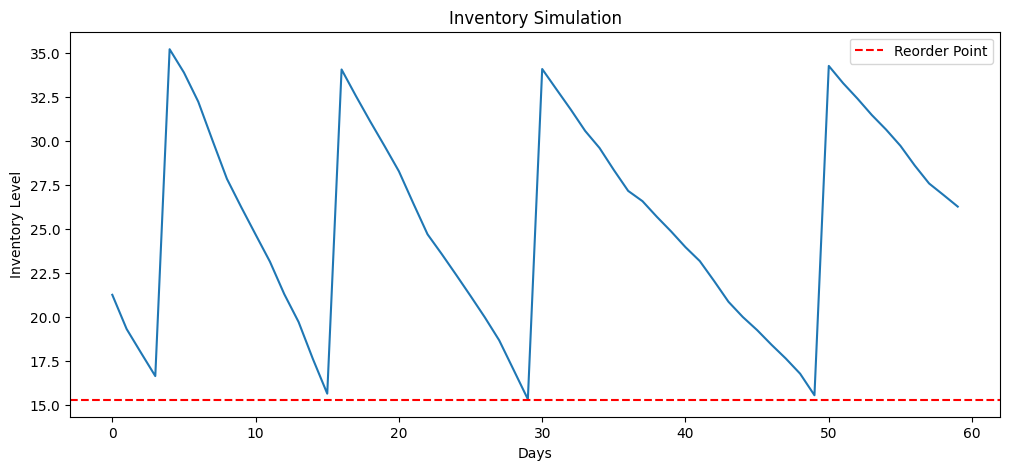

In [23]:
plt.figure(figsize=(12,5))

plt.plot(inventory_levels)
plt.axhline(reorder_point, color="red", linestyle="--", label="Reorder Point")

plt.title("Inventory Simulation")
plt.xlabel("Days")
plt.ylabel("Inventory Level")
plt.legend()

plt.show()

In [27]:
inventory = 30
reorder_point = 15
order_qty = 20

dashboard_rows = []

for day, demand in enumerate(preds[:60]):

    inventory_before = inventory
    inventory_after = max(inventory - demand, 0)

    order = "No"
    if inventory_after <= reorder_point:
        inventory_after += order_qty
        order = "Yes"

    dashboard_rows.append({
        "day": day + 1,
        "forecast_demand": demand,
        "inventory_before": inventory_before,
        "inventory_after_sales": inventory_before - demand,
        "reorder_point": reorder_point,
        "order": order,
        "inventory_final": inventory_after
    })

    inventory = inventory_after

inventory_dashboard = pd.DataFrame(dashboard_rows)
inventory_dashboard.head()

,day,forecast_demand,inventory_before,inventory_after_sales,reorder_point,order,inventory_final
0,1,1.888825,30.000000,28.111175,15,No,28.111175
1,2,1.943886,28.111175,26.167290,15,No,26.167290
2,3,1.345574,26.167290,24.821716,15,No,24.821716
3,4,1.328698,24.821716,23.493018,15,No,23.493018
4,5,1.425799,23.493018,22.067219,15,No,22.067219


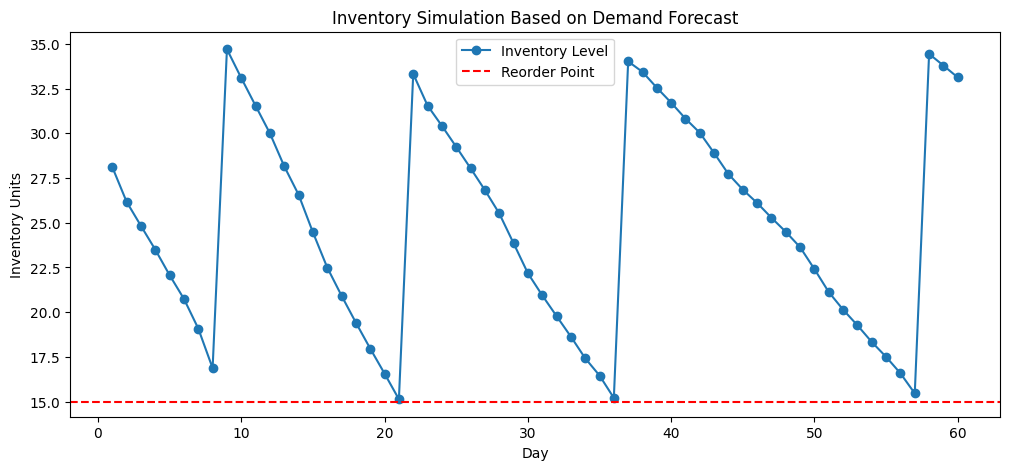

In [28]:
plt.figure(figsize=(12,5))

plt.plot(
    inventory_dashboard["day"],
    inventory_dashboard["inventory_final"],
    marker="o",
    label="Inventory Level"
)

plt.axhline(
    y=reorder_point,
    linestyle="--",
    color="red",
    label="Reorder Point"
)

plt.title("Inventory Simulation Based on Demand Forecast")
plt.xlabel("Day")
plt.ylabel("Inventory Units")
plt.legend()

plt.show()

In [29]:
inventory_dashboard.to_csv("../processed/inventory_simulation.csv", index=False)